In [8]:
# graph.py
from langgraph.graph import StateGraph, END
from IPython.display import Image, display
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate

In [9]:
load_dotenv()

True

In [10]:
class MessageState(TypedDict):
    sender: str
    message: str
    messageType: str
    reply: str

In [11]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [12]:
# Node 1: Message receive karo
def receive_message(state: MessageState) -> MessageState:
    return state

# Router function — messageType dekho
def route_message(state: MessageState) -> str:
    if state.get("messageType") == "audioMessage":
        return "voice"
    return "text"

In [13]:
class Response(BaseModel):
    responce: str = Field(
        ...,
        description="The response to the user's message."
    )

Response_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """You are a helpful and intelligent assistant.

            ## Language Rule (Most Important)
            - ALWAYS detect the language of the user's message.
            - ALWAYS respond in the EXACT same language the user used.
            - NEVER switch languages unless the user switches first.

            ## Examples

            User: "مرحبا، كيف حالك؟"
            Assistant: "مرحباً! أنا بخير، شكراً لك. كيف يمكنني مساعدتك اليوم؟"

            User: "Hello, what is the capital of France?"
            Assistant: "The capital of France is Paris."

            User: "Mujhe biryani ki recipe chahiye."
            Assistant: "Zaroor! Biryani banane ke liye in cheezон ki zaroorat hogi..."

            User: "¿Cuál es la mejor manera de aprender inglés?"
            Assistant: "La mejor manera de aprender inglés es practicar todos los días..."

            User: "كيف أتعلم البرمجة؟"
            Assistant: "يمكنك تعلم البرمجة من خلال البدء بلغة Python لأنها سهلة للمبتدئين..."

            ## Behavior
            - Be helpful, accurate, and concise.
            - Match the user's tone — formal ya casual jo bhi user use kare.
            - If a message is unclear, ask for clarification in the same language they used."""
        ),
        ("human", "Message: {message}"),
    ]
)

llm_responce = llm.with_structured_output(Response)


# Node 2a: Text process karo
def process_message(state: MessageState):

    message = state.get("message", "")

    response: Response = llm_responce.invoke(Response_prompt.format_prompt(message=message))
    
    return {"reply": response.responce}

In [14]:
# Node 2b: Voice handle karo
def process_voice(state: MessageState):
    reply = "Hey your voice msg received"
    return {"reply": reply}

In [15]:
# Node 3: Reply ready
def send_reply(state: MessageState) -> MessageState:
    return state

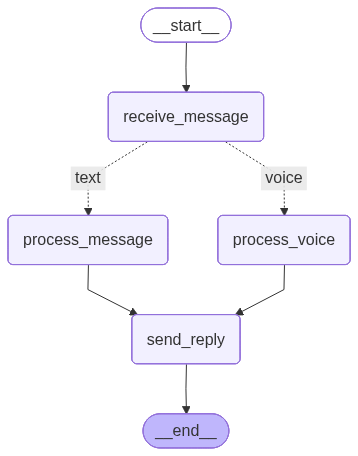

In [16]:
# Graph banao
builder = StateGraph(MessageState)

builder.add_node("receive_message", receive_message)
builder.add_node("process_message", process_message)
builder.add_node("process_voice", process_voice)
builder.add_node("send_reply", send_reply)

builder.set_entry_point("receive_message")

# Conditional edge — router decide karega kaunsa node jayega
builder.add_conditional_edges(
    "receive_message",
    route_message,
    {
        "text": "process_message",
        "voice": "process_voice",
    }
)

builder.add_edge("process_message", "send_reply")
builder.add_edge("process_voice", "send_reply")
builder.add_edge("send_reply", END)

graph = builder.compile()
graph

In [ ]:
# graph.py
from langgraph.graph import StateGraph, END
from typing import TypedDict


class MessageState(TypedDict):
    sender: str
    message: str
    messageType: str
    reply: str

# Node 1: Message receive karo
def receive_message(state: MessageState) -> MessageState:
    print(f"📩 Message aaya from {state['sender']}: {state['message']}")
    return state

# Node 2a: Text process karo (pehle wala kaam)
def process_message(state: MessageState) -> MessageState:
    reply = "Hello! I am from LangGraph 🤖"
    return {**state, "reply": reply}

# Node 2b: Voice handle karo
def process_voice(state: MessageState) -> MessageState:
    reply = "hey your voice msg received"
    return {**state, "reply": reply}

# Node 3: Reply ready
def send_reply(state: MessageState) -> MessageState:
    print(f"📤 Reply ready: {state['reply']}")
    return state

# Router function — messageType dekho
def route_message(state: MessageState) -> str:
    if state.get("messageType") == "audioMessage":
        return "voice"
    return "text"

# Graph banao
builder = StateGraph(MessageState)

builder.add_node("receive_message", receive_message)
builder.add_node("process_message", process_message)
builder.add_node("process_voice", process_voice)
builder.add_node("send_reply", send_reply)

builder.set_entry_point("receive_message")

# Conditional edge — router decide karega kaunsa node jayega
builder.add_conditional_edges(
    "receive_message",
    route_message,
    {
        "text": "process_message",
        "voice": "process_voice",
    }
)

builder.add_edge("process_message", "send_reply")
builder.add_edge("process_voice", "send_reply")
builder.add_edge("send_reply", END)

graph = builder.compile()